# 📊 CodeAlpha Internship — Task 2: Exploratory Data Analysis
**Dataset:** `scrapped_books.csv` — scraped from books.toscrape.com  
**Tools:** pandas, seaborn, matplotlib  
**Columns:** title, price, rating, stock status, book url, category, upc, price(excl tax), price(incl tax), tax, availability, number of reviews, description

## 1. Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
print('✅ Libraries loaded!')

✅ Libraries loaded!


## 2. Load the Dataset

In [17]:
df = pd.read_csv('scrapped_books.csv')

# Clean column names: lowercase, strip spaces, replace special chars
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
)

print('Columns:', df.columns.tolist())
print(f'Shape  : {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Columns: ['title', 'price', 'rating_out_of_5', 'stock_status', 'book_url', 'category', 'upc', 'price_excl._tax', 'price_incl._tax', 'tax', 'availability', 'number_of_reviews', 'description']
Shape  : 60 rows x 13 columns


,title,price,rating_out_of_5,stock_status,book_url,category,upc,price_excl._tax,price_incl._tax,tax,availability,number_of_reviews,description
0,A Light in the Attic,Â£51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...,Poetry,a897fe39b1053632,Â£51.77,Â£51.77,Â£0.00,In stock (22 available),0,It's hard to imagine a world without A Light i...
1,Tipping the Velvet,Â£53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...,Historical Fiction,90fa61229261140a,Â£53.74,Â£53.74,Â£0.00,In stock (20 available),0,"""Erotic and absorbing...Written with starling ..."
2,Soumission,Â£50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...,Fiction,6957f44c3847a760,Â£50.10,Â£50.10,Â£0.00,In stock (20 available),0,"Dans une France assez proche de la nÃ´tre, un ..."
3,Sharp Objects,Â£47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...,Mystery,e00eb4fd7b871a48,Â£47.82,Â£47.82,Â£0.00,In stock (20 available),0,"WICKED above her hipbone, GIRL across her hear..."
4,Sapiens: A Brief History of Humankind,Â£54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...,History,4165285e1663650f,Â£54.23,Â£54.23,Â£0.00,In stock (20 available),0,From a renowned historian comes a groundbreaki...


## 3. Data Overview

In [18]:
print('=== DATA TYPES ==='); print(df.dtypes)
print('\n=== INFO ==='); df.info()

=== DATA TYPES ===
title                object
price                object
rating_out_of_5       int64
stock_status         object
book_url             object
category             object
upc                  object
price_excl._tax      object
price_incl._tax      object
tax                  object
availability         object
number_of_reviews     int64
description          object
dtype: object

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   title              60 non-null     object
 1   price              60 non-null     object
 2   rating_out_of_5    60 non-null     int64 
 3   stock_status       60 non-null     object
 4   book_url           60 non-null     object
 5   category           60 non-null     object
 6   upc                60 non-null     object
 7   price_excl._tax    60 non-null     object
 8   price_incl.

In [19]:
print('=== STATISTICAL SUMMARY ===')
df.describe(include='all').T

=== STATISTICAL SUMMARY ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,60,60,A Light in the Attic,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,60,59,Â£44.18,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating_out_of_5,60.0,NaN,NaN,NaN,3.0,1.507046,1.0,1.75,3.0,4.0,5.0
stock_status,60,1,In stock,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
book_url,60,60,https://books.toscrape.com/catalogue/a-light-i...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,60,25,Poetry,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
upc,60,60,a897fe39b1053632,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_excl._tax,60,59,Â£44.18,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_incl._tax,60,59,Â£44.18,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax,60,1,Â£0.00,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Cleaning

In [20]:
# Missing values
missing = df.isnull().sum()
print('=== MISSING VALUES ===')
print(missing[missing > 0] if missing.any() else 'No missing values ✅')

# Duplicates
dupes = df.duplicated().sum()
print(f'\nDuplicate rows: {dupes}')
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'Dropped {dupes} duplicates.')

=== MISSING VALUES ===
No missing values ✅

Duplicate rows: 0


In [21]:
# Fix numeric columns — strip £ and Â symbol if present
for col in ['price', 'price_excl._tax', 'price_incl._tax', 'tax']:
    if col in df.columns:
        df[col] = (
            df[col].astype(str)
            .str.replace('£', '', regex=False)
            .str.replace('Â', '', regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Rename columns for convenience
rename_map = {}
if 'price_excl._tax' in df.columns: rename_map['price_excl._tax'] = 'price_ex_tax'
if 'price_incl._tax' in df.columns: rename_map['price_incl._tax'] = 'price_in_tax'
if 'number_of_reviews' in df.columns: rename_map['number_of_reviews'] = 'no_of_reviews'
df.rename(columns=rename_map, inplace=True)

# Rating — ensure numeric
rating_col = 'rating_out_of_5' if 'rating_out_of_5' in df.columns else 'rating'
df['rating'] = pd.to_numeric(
    df[rating_col].astype(str).str.extract(r'(\d+\.?\d*)')[0],
    errors='coerce'
)

# no_of_reviews → integer
if 'no_of_reviews' in df.columns:
    df['no_of_reviews'] = pd.to_numeric(df['no_of_reviews'], errors='coerce').fillna(0).astype(int)

# Derived columns
df['description_length'] = df['description'].fillna('').apply(len)
df['in_stock'] = df['availability'].astype(str).str.lower().str.contains('in stock')
df['price_band'] = pd.cut(
    df['price'],
    bins=[0, 10, 20, 30, 60],
    labels=['Budget (<£10)', 'Mid (£10-20)', 'Premium (£20-30)', 'Luxury (£30+)']
)

print('✅ Cleaning done. Shape:', df.shape)
df[['title', 'rating', 'price', 'category', 'in_stock']].head(8)

✅ Cleaning done. Shape: (60, 17)


,title,rating,price,category,in_stock
0,A Light in the Attic,3,51.77,Poetry,True
1,Tipping the Velvet,1,53.74,Historical Fiction,True
2,Soumission,1,50.10,Fiction,True
3,Sharp Objects,4,47.82,Mystery,True
4,Sapiens: A Brief History of Humankind,5,54.23,History,True
5,The Requiem Red,1,22.65,Young Adult,True
6,The Dirty Little Secrets of Getting Your Dream...,4,33.34,Business,True
7,The Coming Woman: A Novel Based on the Life of...,3,17.93,Default,True


## 5. Univariate Analysis

### 5.1 Rating Distribution

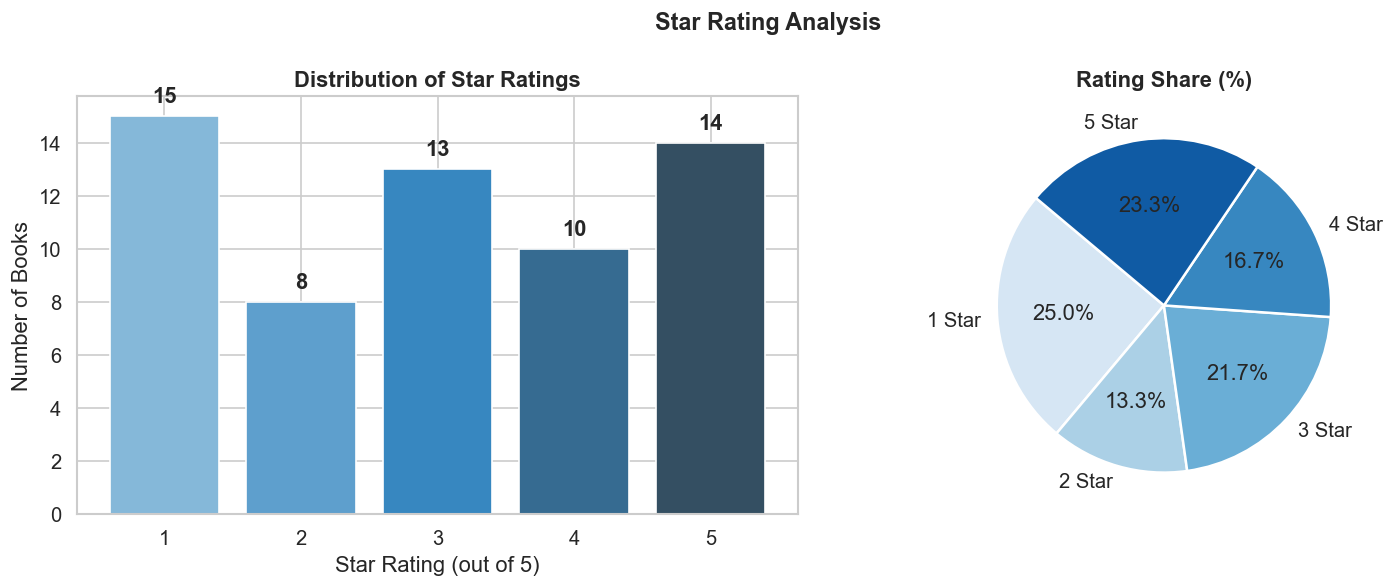

💡 Most common rating: 1 stars — 15 books


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
rating_counts = df['rating'].value_counts().sort_index()

axes[0].bar(rating_counts.index.astype(str), rating_counts.values,
            color=sns.color_palette('Blues_d', len(rating_counts)), edgecolor='white')
axes[0].set_title('Distribution of Star Ratings', fontweight='bold')
axes[0].set_xlabel('Star Rating (out of 5)')
axes[0].set_ylabel('Number of Books')
for x, v in zip(rating_counts.index, rating_counts.values):
    axes[0].text(str(x), v + 0.5, str(v), ha='center', fontweight='bold')

axes[1].pie(rating_counts.values,
            labels=[f'{int(i)} Star' for i in rating_counts.index],
            autopct='%1.1f%%',
            colors=sns.color_palette('Blues', len(rating_counts)),
            startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Rating Share (%)', fontweight='bold')

plt.suptitle('Star Rating Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot1_rating_distribution.png', bbox_inches='tight')
plt.show()
print('💡 Most common rating:', int(rating_counts.idxmax()), 'stars —', rating_counts.max(), 'books')

### 5.2 Price Distribution

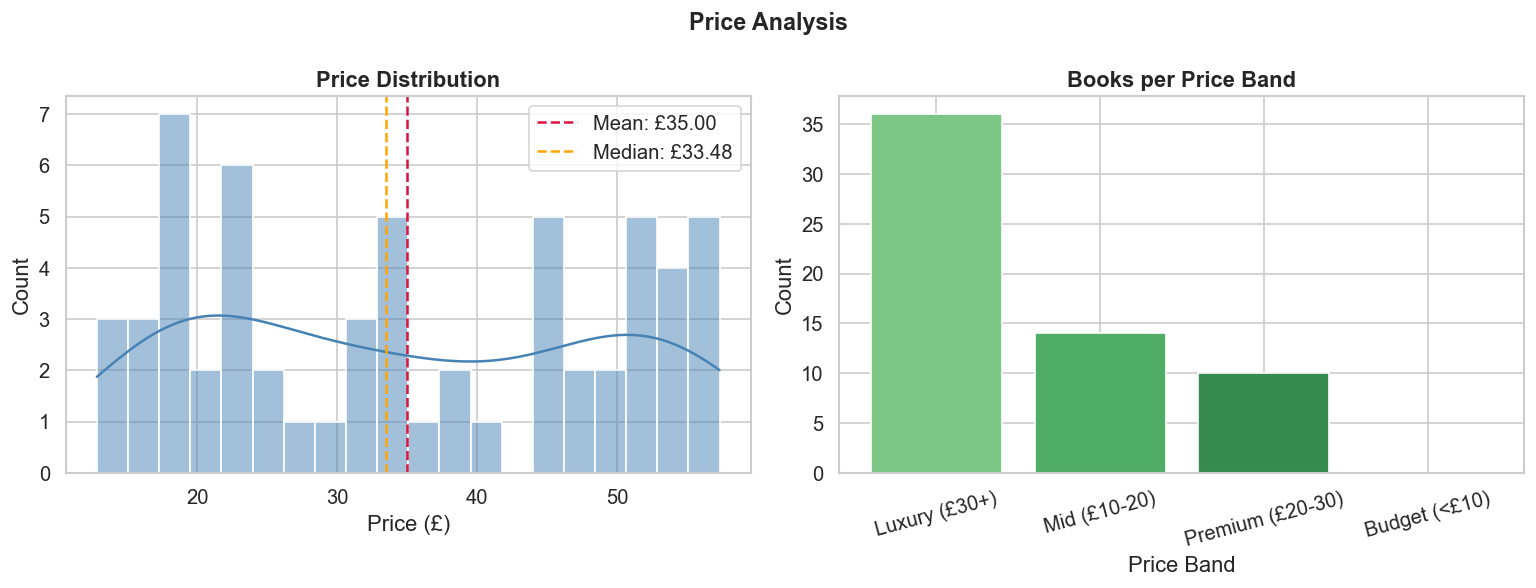

💡 Price range: £12.84 – £57.31


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df['price'].dropna(), bins=20, kde=True,
             color='steelblue', ax=axes[0], edgecolor='white')
axes[0].axvline(df['price'].mean(),   color='crimson', linestyle='--',
                label=f"Mean: £{df['price'].mean():.2f}")
axes[0].axvline(df['price'].median(), color='orange',  linestyle='--',
                label=f"Median: £{df['price'].median():.2f}")
axes[0].legend()
axes[0].set_title('Price Distribution', fontweight='bold')
axes[0].set_xlabel('Price (£)')

band_counts = df['price_band'].value_counts()
axes[1].bar(band_counts.index.astype(str), band_counts.values,
            color=sns.color_palette('Greens_d', len(band_counts)), edgecolor='white')
axes[1].set_title('Books per Price Band', fontweight='bold')
axes[1].set_xlabel('Price Band')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Price Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_price_distribution.png', bbox_inches='tight')
plt.show()
print(f'💡 Price range: £{df["price"].min():.2f} – £{df["price"].max():.2f}')

### 5.3 Top Categories

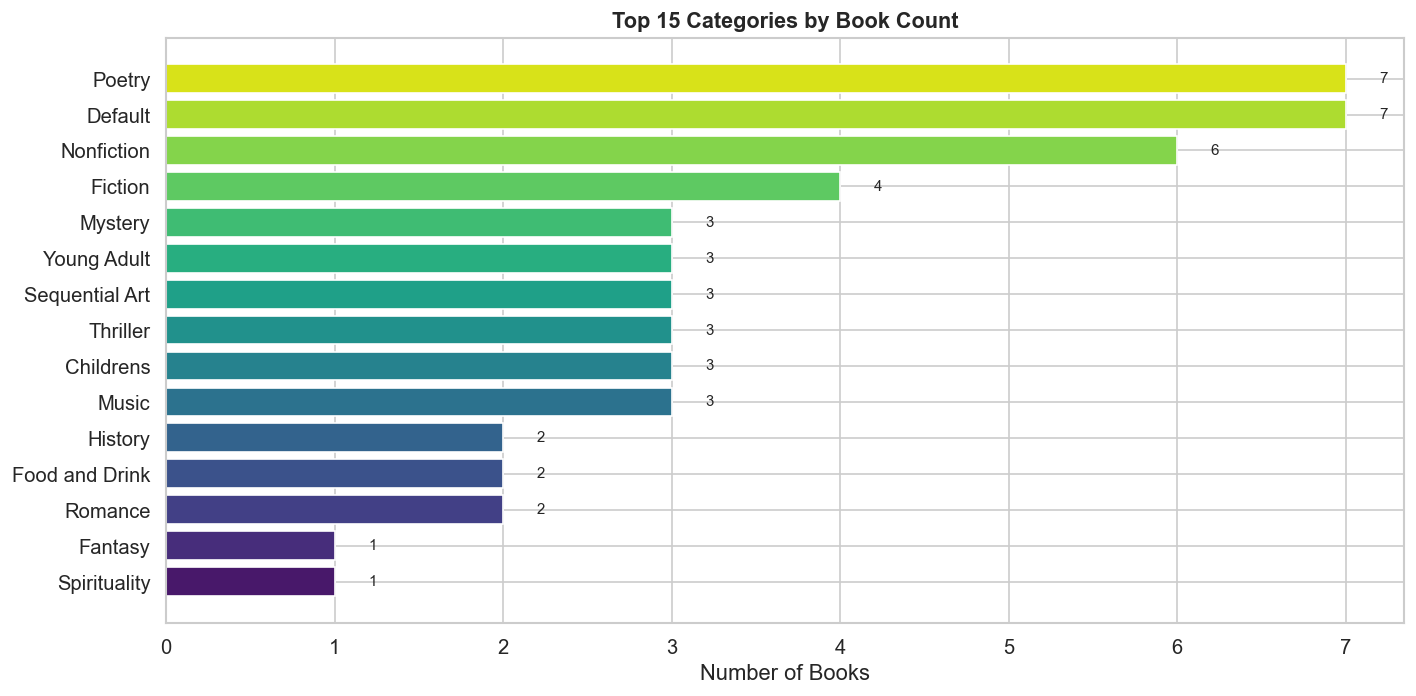

💡 Most common category: Poetry — 7 books


In [24]:
top_cats = df['category'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_cats.index[::-1], top_cats.values[::-1],
               color=sns.color_palette('viridis', len(top_cats)))
ax.set_title('Top 15 Categories by Book Count', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of Books')
for bar, val in zip(bars, top_cats.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot3_top_categories.png', bbox_inches='tight')
plt.show()
print('💡 Most common category:', top_cats.index[0], '—', top_cats.iloc[0], 'books')

### 5.4 Stock Availability

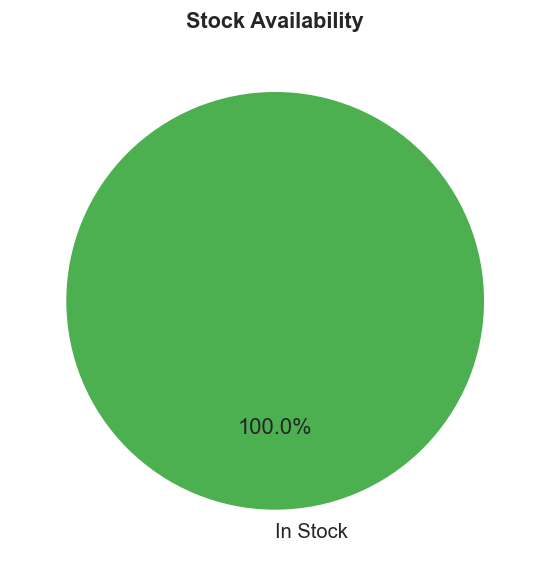

💡 100.0% of books are in stock.


In [25]:
stock_counts = df['in_stock'].value_counts()
fig, ax = plt.subplots(figsize=(6, 5))
labels = ['In Stock', 'Out of Stock'][:len(stock_counts)]
colors = ['#4CAF50', '#F44336'][:len(stock_counts)]
ax.pie(stock_counts.values,
       labels=labels,
       autopct='%1.1f%%',
       colors=colors,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2},
       startangle=90)
ax.set_title('Stock Availability', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot4_availability.png', bbox_inches='tight')
plt.show()
pct = df['in_stock'].mean() * 100
print(f'💡 {pct:.1f}% of books are in stock.')

## 6. Bivariate Analysis

### 6.1 Rating vs Price

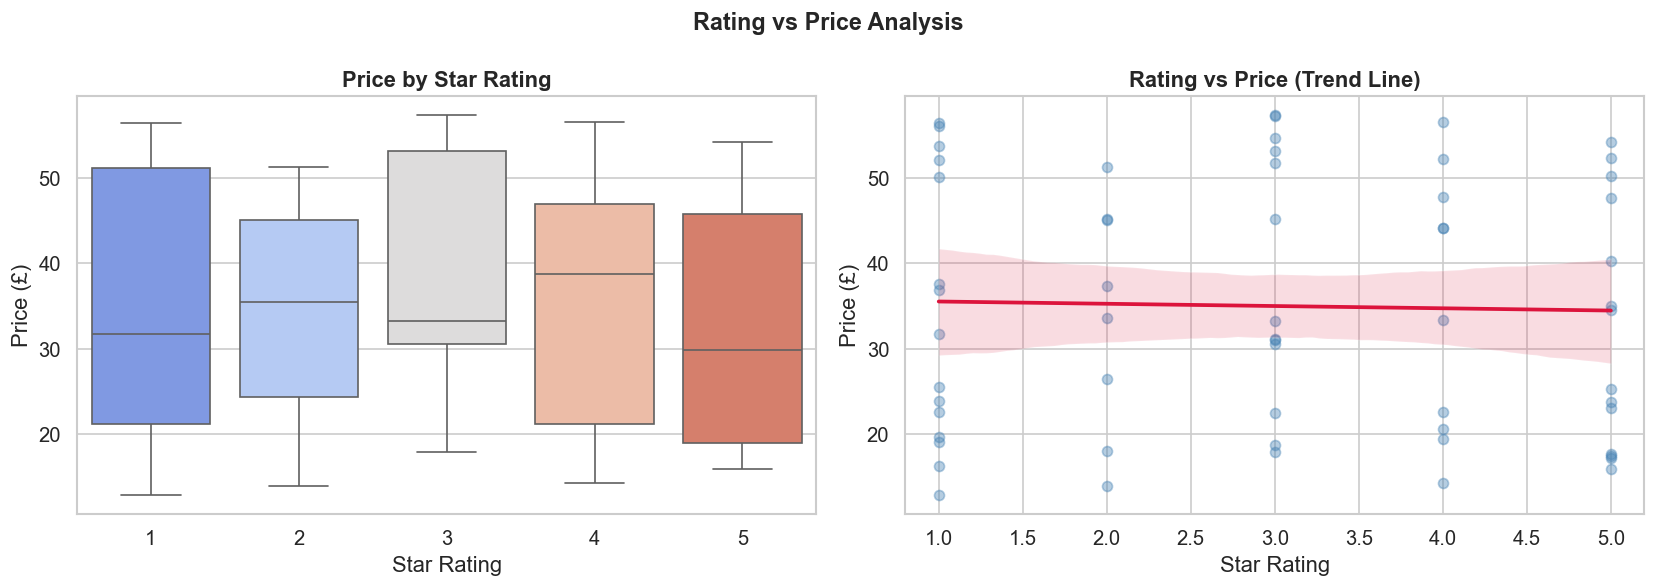

💡 Pearson correlation (rating vs price): -0.027


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='rating', y='price', palette='coolwarm', ax=axes[0])
axes[0].set_title('Price by Star Rating', fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Price (£)')

sns.regplot(data=df, x='rating', y='price',
            scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
            line_kws={'color': 'crimson'}, ax=axes[1])
axes[1].set_title('Rating vs Price (Trend Line)', fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Price (£)')

corr = df[['rating', 'price']].corr().iloc[0, 1]
plt.suptitle('Rating vs Price Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_rating_vs_price.png', bbox_inches='tight')
plt.show()
print(f'💡 Pearson correlation (rating vs price): {corr:.3f}')

### 6.2 Average Rating by Category

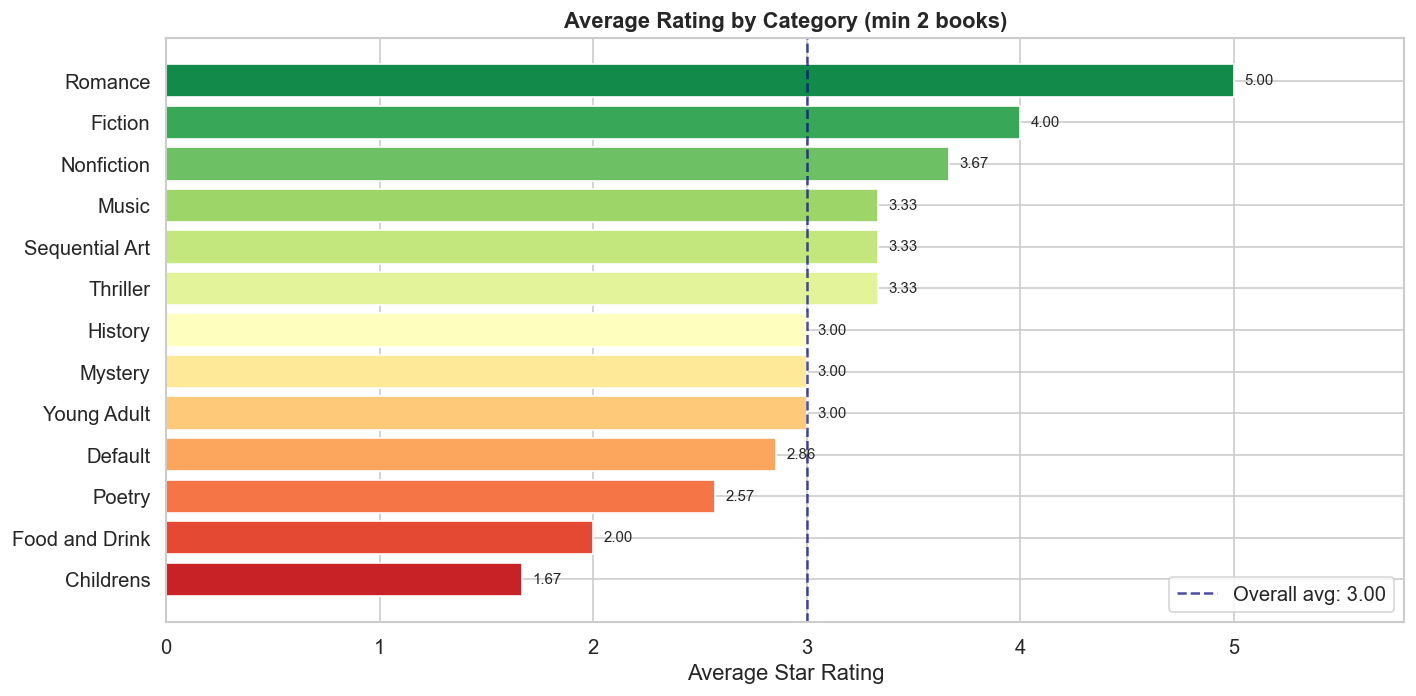

💡 Top rated category: Romance — 5.0 stars


In [27]:
cat_rating = (
    df.groupby('category')['rating']
    .agg(['mean', 'count'])
    .query('count >= 2')
    .sort_values('mean', ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(cat_rating['category'][::-1], cat_rating['mean'][::-1],
               color=sns.color_palette('RdYlGn', len(cat_rating)))
ax.axvline(df['rating'].mean(), color='navy', linestyle='--', alpha=0.7,
           label=f'Overall avg: {df["rating"].mean():.2f}')
ax.set_xlim(0, 5.8)
ax.set_title('Average Rating by Category (min 2 books)', fontweight='bold')
ax.set_xlabel('Average Star Rating')
ax.legend()
for bar, val in zip(bars, cat_rating['mean'][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot6_category_avg_rating.png', bbox_inches='tight')
plt.show()
print('💡 Top rated category:', cat_rating.iloc[0]['category'],
      '—', round(cat_rating.iloc[0]['mean'], 2), 'stars')

### 6.3 Price (ex tax) vs Price (inc tax) coloured by Rating

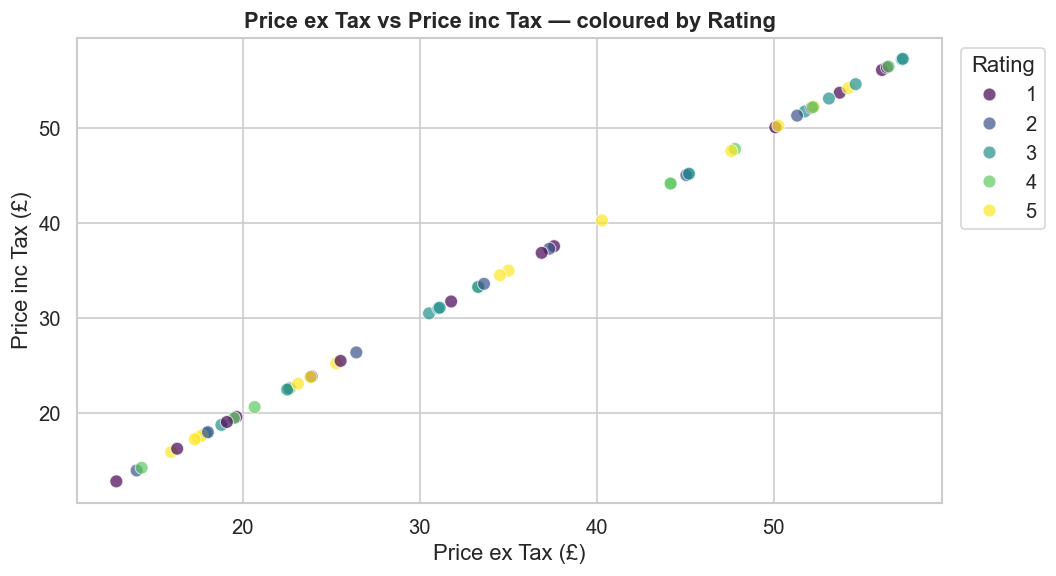

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x='price_ex_tax', y='price_in_tax',
                hue='rating', palette='viridis', alpha=0.7, s=60, ax=ax)
ax.set_title('Price ex Tax vs Price inc Tax — coloured by Rating', fontweight='bold')
ax.set_xlabel('Price ex Tax (£)')
ax.set_ylabel('Price inc Tax (£)')
ax.legend(title='Rating', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot7_tax_scatter.png', bbox_inches='tight')
plt.show()

### 6.4 Number of Reviews vs Rating

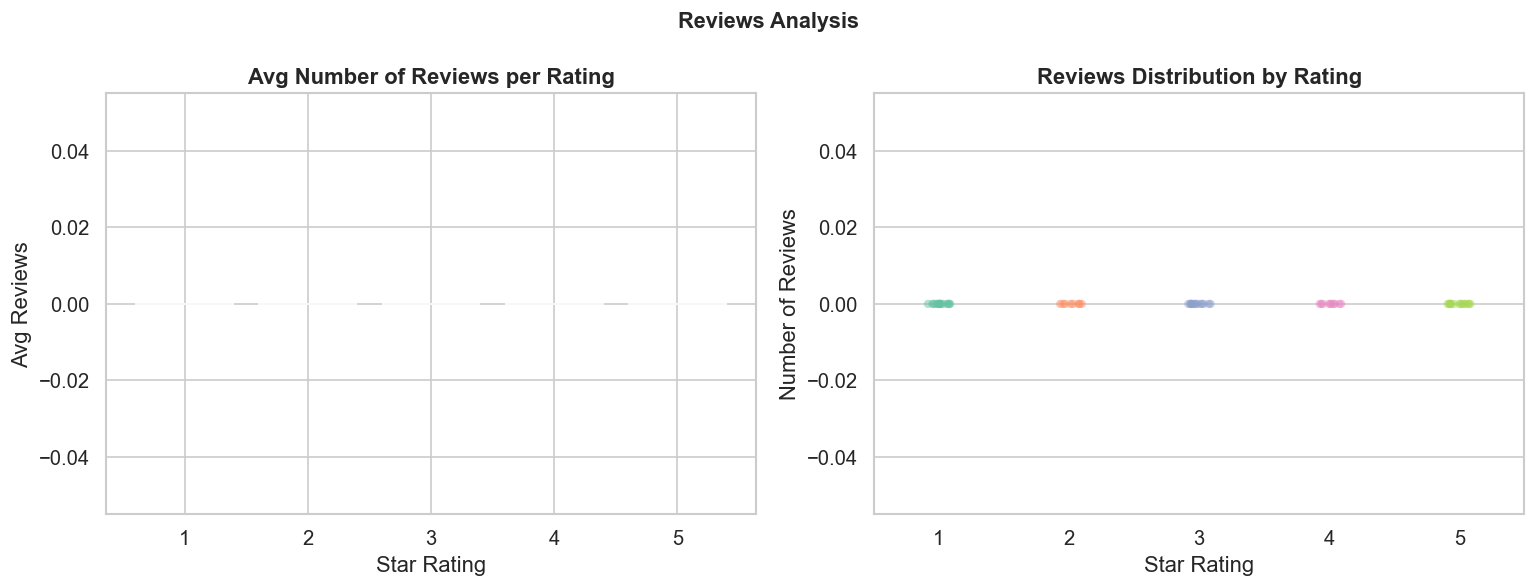

In [29]:
if 'no_of_reviews' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    avg_reviews = df.groupby('rating')['no_of_reviews'].mean()
    axes[0].bar(avg_reviews.index.astype(str), avg_reviews.values,
                color=sns.color_palette('Purples_d', len(avg_reviews)), edgecolor='white')
    axes[0].set_title('Avg Number of Reviews per Rating', fontweight='bold')
    axes[0].set_xlabel('Star Rating')
    axes[0].set_ylabel('Avg Reviews')

    sns.stripplot(data=df, x='rating', y='no_of_reviews',
                  palette='Set2', alpha=0.5, jitter=True, ax=axes[1])
    axes[1].set_title('Reviews Distribution by Rating', fontweight='bold')
    axes[1].set_xlabel('Star Rating')
    axes[1].set_ylabel('Number of Reviews')

    plt.suptitle('Reviews Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot8_reviews_vs_rating.png', bbox_inches='tight')
    plt.show()

## 7. Multivariate Analysis

### 7.1 Category × Rating Heatmap

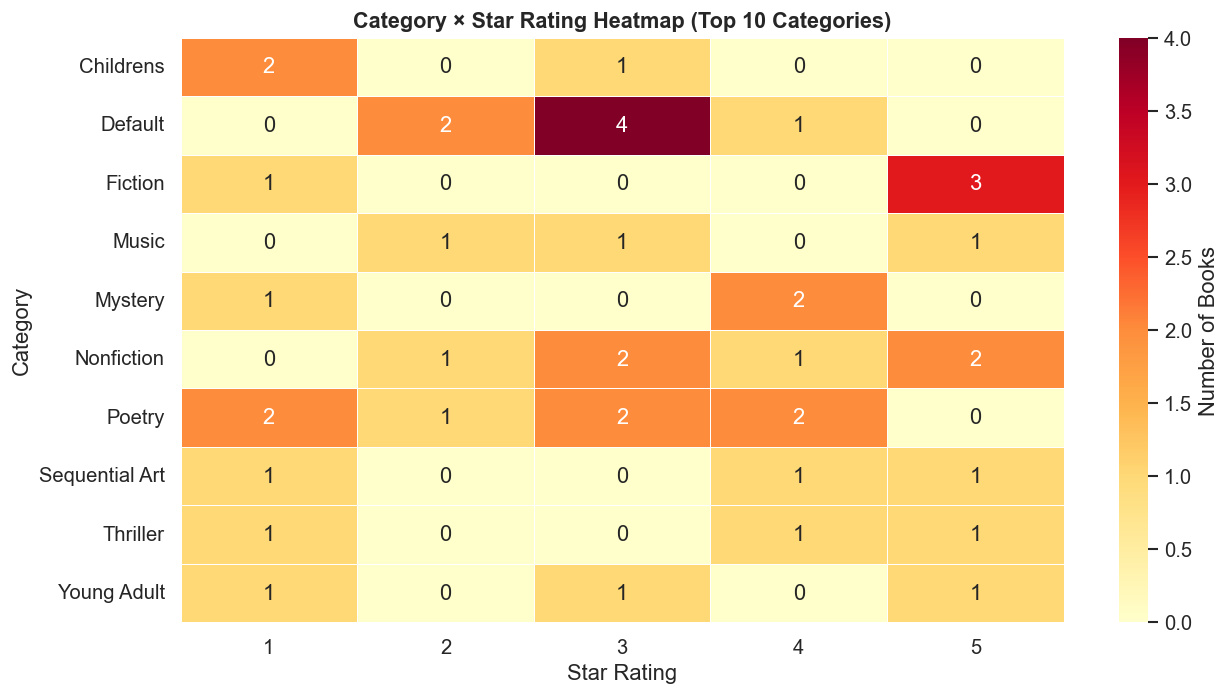

In [30]:
top10 = df['category'].value_counts().head(10).index
pivot = (
    df[df['category'].isin(top10)]
    .pivot_table(index='category', columns='rating',
                 values='title', aggfunc='count', fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Number of Books'}, ax=ax)
ax.set_title('Category × Star Rating Heatmap (Top 10 Categories)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Star Rating')
ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('plot9_category_rating_heatmap.png', bbox_inches='tight')
plt.show()

### 7.2 Correlation Heatmap — All Numeric Columns

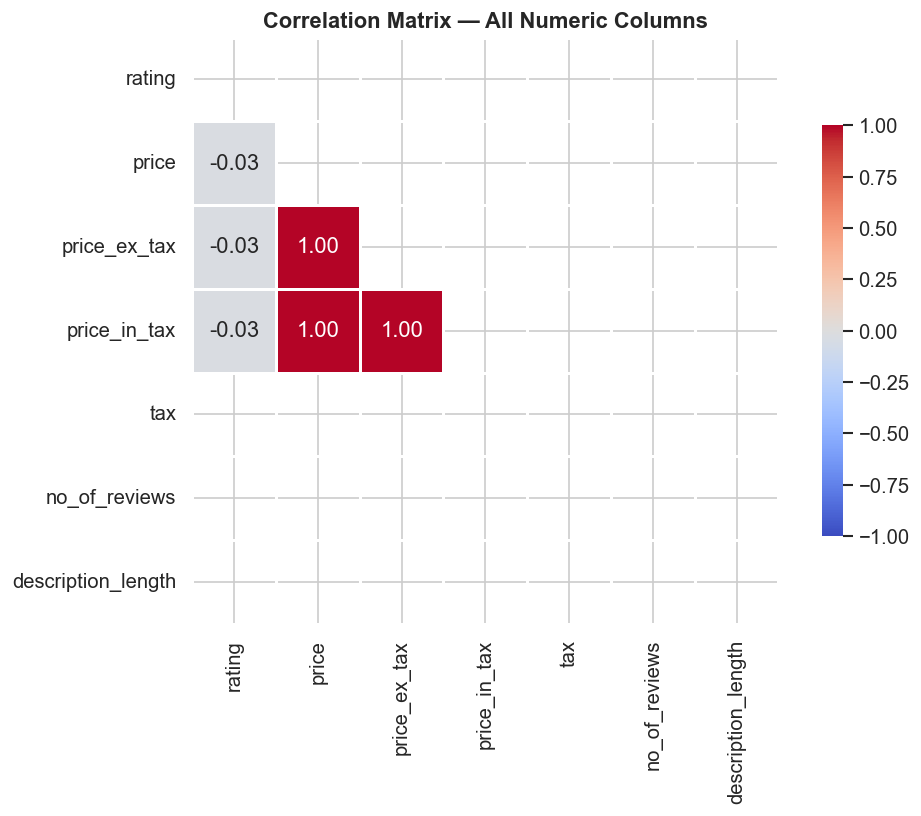

In [31]:
num_cols = ['rating', 'price', 'price_ex_tax', 'price_in_tax',
            'tax', 'no_of_reviews', 'description_length']
num_cols = [c for c in num_cols if c in df.columns]
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.8, square=True, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Correlation Matrix — All Numeric Columns', fontweight='bold')
plt.tight_layout()
plt.savefig('plot10_correlation.png', bbox_inches='tight')
plt.show()

## 8. Outlier Detection

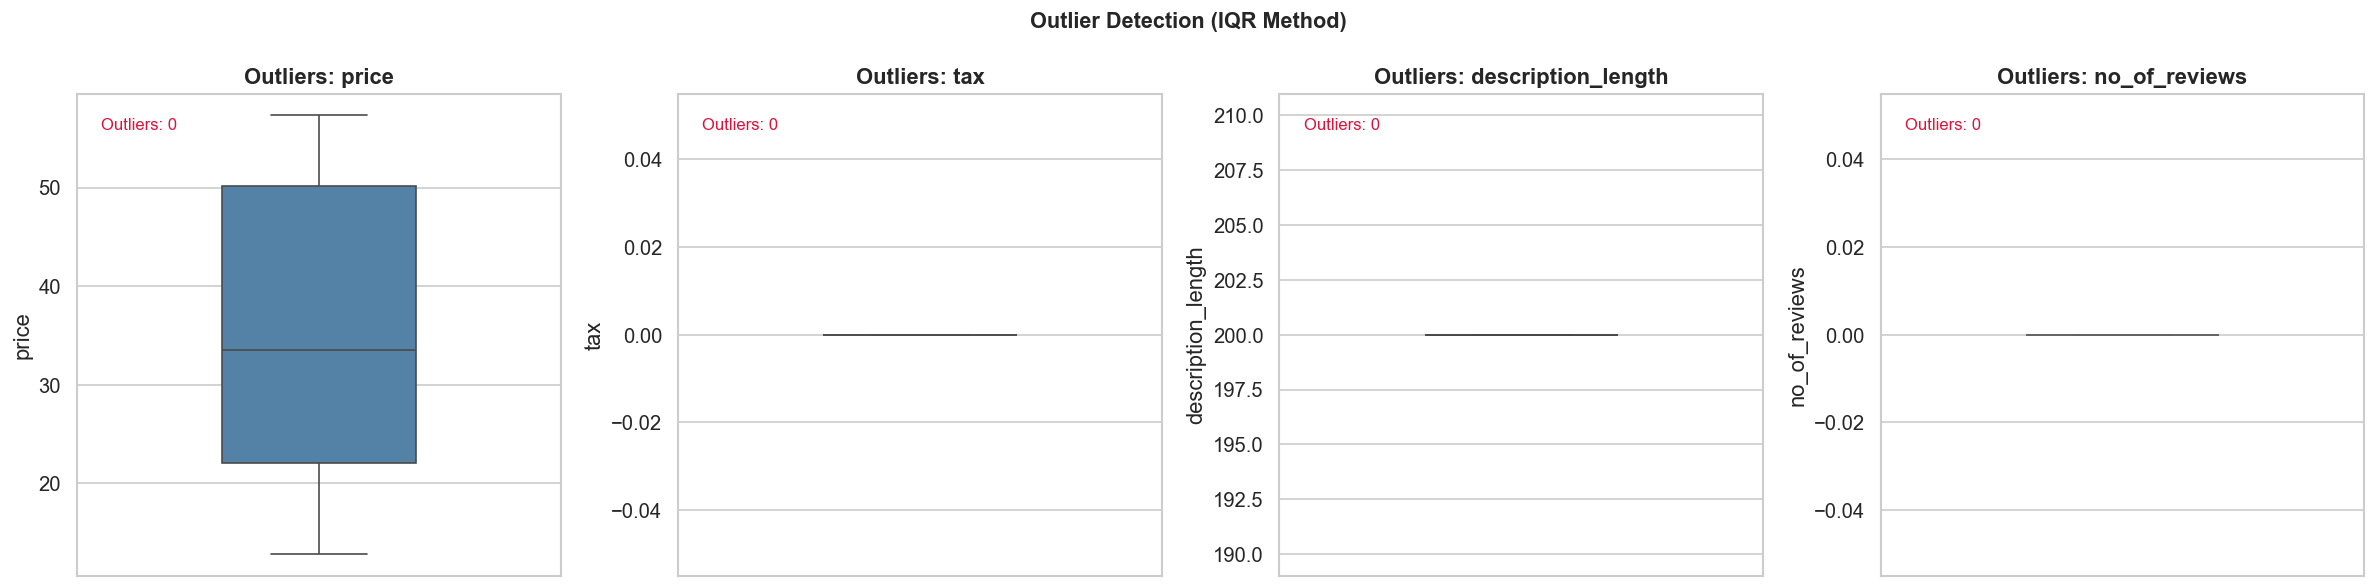

In [32]:
check_cols = [c for c in ['price', 'tax', 'description_length', 'no_of_reviews'] if c in df.columns]
fig, axes = plt.subplots(1, len(check_cols), figsize=(5 * len(check_cols), 5))
if len(check_cols) == 1:
    axes = [axes]

colors = ['steelblue', 'darkorange', 'mediumseagreen', 'mediumpurple']
for ax, col, color in zip(axes, check_cols, colors):
    sns.boxplot(y=df[col].dropna(), color=color, ax=ax, width=0.4)
    ax.set_title(f'Outliers: {col}', fontweight='bold')
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    ax.text(0.05, 0.95, f'Outliers: {n_out}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top', color='crimson')

plt.suptitle('Outlier Detection (IQR Method)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot11_outliers.png', bbox_inches='tight')
plt.show()

## 9. Summary of Key Findings

In [33]:
print('=' * 60)
print('   📋 EDA SUMMARY — KEY FINDINGS')
print('=' * 60)
print(f'Total books analysed        : {len(df)}')
print(f'Unique categories           : {df["category"].nunique()}')
print(f'Average star rating         : {df["rating"].mean():.2f} / 5')
print(f'Most common rating          : {int(df["rating"].mode()[0])} stars')
print(f'Average price               : £{df["price"].mean():.2f}')
print(f'Price range                 : £{df["price"].min():.2f} – £{df["price"].max():.2f}')
print(f'Most popular category       : {df["category"].value_counts().index[0]}')
print(f'Top rated category          : {cat_rating.iloc[0]["category"]} ({cat_rating.iloc[0]["mean"]:.2f} stars)')
print(f'Rating–Price correlation    : {df[["rating", "price"]].corr().iloc[0,1]:.3f}')
if 'no_of_reviews' in df.columns:
    print(f'Total reviews in dataset    : {df["no_of_reviews"].sum()}')
print(f'% Books in stock            : {df["in_stock"].mean()*100:.1f}%')
print('=' * 60)
print('✅ 11 plots saved as PNG files in the same folder.')
print('✅ Cleaned CSV ready for Task 3 (Tableau) & Task 4 (Sentiment).')

   📋 EDA SUMMARY — KEY FINDINGS
Total books analysed        : 60
Unique categories           : 25
Average star rating         : 3.00 / 5
Most common rating          : 1 stars
Average price               : £35.00
Price range                 : £12.84 – £57.31
Most popular category       : Poetry
Top rated category          : Romance (5.00 stars)
Rating–Price correlation    : -0.027
Total reviews in dataset    : 0
% Books in stock            : 100.0%
✅ 11 plots saved as PNG files in the same folder.
✅ Cleaned CSV ready for Task 3 (Tableau) & Task 4 (Sentiment).


## 10. Export Cleaned Data for Tasks 3 & 4

In [34]:
df.to_csv('books_cleaned.csv', index=False)
print('✅ Saved: books_cleaned.csv')
print('   → Task 3 : import into Tableau for your dashboard')
print('   → Task 4 : run sentiment analysis on the description column')

✅ Saved: books_cleaned.csv
   → Task 3 : import into Tableau for your dashboard
   → Task 4 : run sentiment analysis on the description column
